In [194]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import minimize, minimize_scalar
from scipy.integrate import quad  # 引入积分模块

try:
    from IPython.display import display
except ImportError:
    display = print

# initial set up
DEMAND = 1.0

t1 = lambda w: w
t2 = lambda w: w
t3 = lambda w: w + 1.0

C = lambda x: np.array([t1(x[0]), t2(x[1]), t3(x[2])])

Z = lambda x: quad(t1, 0, x[0])[0] + quad(t2, 0, x[1])[0] + quad(t3, 0, x[2])[0]

def AON(c, demand=DEMAND):
    y = np.zeros(len(c))
    min_index = np.argmin(c)
    y[min_index] = demand
    return y

# AON = lambda c, demand=DEMAND: np.eye(len(c))[np.argmin(c)] * demand


In [195]:
def solve_ue_by_scipy():  # use scipy.optimize.minimize to solve problem
    x0 = np.array([1/3, 1/3, 1/3])

    constraints = {
        "type": "eq",
        "fun": lambda x: np.sum(x) - DEMAND
    }

    bounds = [(0.0, DEMAND), (0.0, DEMAND), (0.0, DEMAND)]

    result = minimize(
        Z,
        x0,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints
    )

    return result

In [196]:
# line search

def phi(x, d, alpha):
    return Z(x + alpha * d)


def phi_prime(x, d, alpha):
    return np.dot(d, C(x + alpha * d))


# Method A: scipy traditional scalar minimization

def scipy_line_search(x, d, alpha_max=1.0):
    result = minimize_scalar(
        lambda a: phi(x, d, a),
        bounds=(0.0, alpha_max),
        method="bounded"
    )

    alpha = result.x
    evals = result.nfev # # of func evaluations

    return alpha, 0.0, alpha_max, evals


# Method B: bisection on full interval

def bisection_line_search(x, d, a=0.0, b=1.0, eps_ls=1e-4):

    left = a
    right = b

    # Check boundary derivative signs
    fa = phi_prime(x, d, left)
    fb = phi_prime(x, d, right)

    if fa >= 0:
        return left, a, b, 0

    if fb <= 0:
        return right, a, b, 0

    I0 = right - left
    N_ls = int(np.ceil((np.log(2 * eps_ls) - np.log(I0)) / np.log(0.5)))
    N_ls = max(N_ls, 0)

    for _ in range(N_ls):
        mid = 0.5 * (left + right)
        fm = phi_prime(x, d, mid)

        if fm < 0:
            left = mid
        else:
            right = mid

    alpha = 0.5 * (left + right)

    return alpha, a, b, N_ls

# Method C: golden-section search on full interval

def golden_section_line_search(x, d, a=0.0, b=1.0, eps_ls=1e-4, max_iter=200):
    """
    Paper-style golden-section search.

    interval_reductions: 对应论文公式 N_ls
    function_evals: 实际调用 phi 的次数
    """
    left = a
    right = b

    r = (np.sqrt(5) - 1) / 2  # about 0.618

    u = right - r * (right - left)
    v = left + r * (right - left)

    fu = phi(x, d, u)
    fv = phi(x, d, v)

    interval_reductions = 0
    function_evals = 2

    while (right - left) > 2 * eps_ls and interval_reductions < max_iter:
        if fu > fv:
            left = u
            u = v
            fu = fv

            v = left + r * (right - left)
            fv = phi(x, d, v)
            function_evals += 1

        else:
            right = v
            v = u
            fv = fu

            u = right - r * (right - left)
            fu = phi(x, d, u)
            function_evals += 1

        interval_reductions += 1

    alpha = 0.5 * (left + right)

    return alpha, a, b, interval_reductions, function_evals

In [197]:
# Two self-adaptive interval strategies


# Method D1: zero-order self-adaptive interval

def zero_order_adaptive_interval(x, d, alpha_prev, alpha_max=1.0, beta=2.0):

    eps = 1e-12 # epsilon

    c = np.clip(alpha_prev, eps, alpha_max)
    a = max(0.0, c / beta)
    b = min(alpha_max, c * beta)

    fa = phi(x, d, a)
    fc = phi(x, d, c)
    fb = phi(x, d, b)

    evals = 3

    for _ in range(100):
        # optimum lies to the left
        if fa < fc and a > 0.0:
            b, fb = c, fc
            c, fc = a, fa
            a = max(0.0, a / beta)
            fa = phi(x, d, a)
            evals += 1

        # optimum lies to the right
        elif fb < fc and b < alpha_max:
            a, fa = c, fc
            c, fc = b, fb
            b = min(alpha_max, b * beta)
            fb = phi(x, d, b)
            evals += 1

        # current interval brackets the minimum
        else:
            return a, b, evals

    return a, b, evals


def adaptive_golden_line_search(x, d, alpha_prev, alpha_max=1.0, beta=2.0):
    a, b, interval_evals = zero_order_adaptive_interval(
        x, d, alpha_prev, alpha_max=alpha_max, beta=beta
    )

    # Fix: golden_section_line_search returns 5 values now
    alpha, _, _, int_red, func_evals = golden_section_line_search(x, d, a=a, b=b)

    return alpha, a, b, interval_evals + func_evals


# Method D2: first-order self-adaptive interval

def first_order_adaptive_interval(x, d, alpha_prev, alpha_max=1.0, beta=2.0):
    eps = 1e-12

    a = np.clip(alpha_prev, eps, alpha_max)
    b = a

    ga = phi_prime(x, d, a)
    gb = ga

    evals = 1

    for _ in range(100):
        # derivative is already positive, optimum lies to the left
        if ga > 0:
            b = a
            gb = ga

            if a <= eps:
                return 0.0, b, evals

            a = max(0.0, a / beta)
            ga = phi_prime(x, d, a)
            evals += 1

        # derivative is negative, optimum lies to the right
        elif gb < 0 and b < alpha_max:
            a = b
            ga = gb

            b = min(alpha_max, b * beta)
            gb = phi_prime(x, d, b)
            evals += 1

        # we have phi'(a) <= 0 <= phi'(b)
        else:
            return a, b, evals

    return a, b, evals


def adaptive_bisection_line_search(x, d, alpha_prev, alpha_max=1.0, beta=2.0):
    a, b, interval_evals = first_order_adaptive_interval(
        x, d, alpha_prev, alpha_max=alpha_max, beta=beta
    )

    alpha, _, _, search_evals = bisection_line_search(x, d, a=a, b=b, eps_ls=1e-4)

    return alpha, a, b, interval_evals + search_evals


In [198]:
def run_frank_wolfe(
    method,
    x0=np.array([0.2, 0.6, 0.2]),
    max_iter=200,
    fw_tol=0.0,
    eps_ls=1e-4,
    beta=2.0
):

    x = x0.astype(float).copy()

    history = []
    alpha_prev = 1.0

    for k in range(max_iter):
        # Fix: Use defined functions C, AON, and Z instead of undefined ones
        c = C(x)
        y = AON(c)
        d = y - x

        fw_gap = np.dot(c, x - y)
        Z_val = Z(x)  # Fix: renamed to Z_val to avoid shadowing function Z

        # Stop if close to UE
        if fw_gap < fw_tol:
            history.append({
                "iter": k,
                "x1": x[0],
                "x2": x[1],
                "x3": x[2],
                "Z": Z_val,
                "gap": fw_gap,
                "alpha": 0.0,
                "interval_a": np.nan,
                "interval_b": np.nan,
                "evals": 0,
                "aon_path": np.argmin(c) + 1
            })
            break

        # Choose line-search method
        if method == "scipy":
            alpha, a, b, evals = scipy_line_search(x, d)

        elif method == "bisection":
            alpha, a, b, evals = bisection_line_search(x, d, a=0.0, b=1.0, eps_ls=eps_ls)

        elif method == "golden":
            # Fix: golden_section_line_search returns 5 values
            alpha, a, b, int_red, evals = golden_section_line_search(x, d, a=0.0, b=1.0)

        elif method == "adaptive_bisection":
            if k == 0:
                alpha, a, b, evals = bisection_line_search(x, d, a=0.0, b=1.0, eps_ls=eps_ls)
            else:
                alpha, a, b, evals = adaptive_bisection_line_search(
                    x, d, alpha_prev, beta=beta
                )

        elif method == "adaptive_golden":
            if k == 0:
                # Fix: golden_section_line_search returns 5 values
                alpha, a, b, int_red, evals = golden_section_line_search(x, d, a=0.0, b=1.0)
            else:
                alpha, a, b, evals = adaptive_golden_line_search(
                    x, d, alpha_prev, beta=beta
                )
        else:
            raise ValueError(f"Unknown method: {method}")

        history.append({
            "iter": k,
            "x1": x[0],
            "x2": x[1],
            "x3": x[2],
            "Z": Z_val,
            "gap": fw_gap,
            "alpha": alpha,
            "interval_a": a,
            "interval_b": b,
            "evals": evals,
            "aon_path": np.argmin(c) + 1
        })

        # FW update
        x = x + alpha * d
        alpha_prev = max(alpha, 1e-12)

    df = pd.DataFrame(history)

    return x, df


In [199]:
import time

#UE solve
result = solve_ue_by_scipy()

print("Solving UE directly by scipy")
print("x* =", result.x)
print("cost(x*) =", C(result.x))
print("Z(x*) =", Z(result.x))
print()


methods = [
    "scipy",
    "bisection",
    "golden",
    "adaptive_bisection",
    "adaptive_golden"
]

summary = []
results = {}

for method in methods:
    start_time = time.time()
    x_final, df = run_frank_wolfe(method=method, max_iter=200)
    end_time = time.time()
    runtime = end_time - start_time

    results[method] = df

    summary.append({
        "method": method,
        "iterations": len(df),
        "final_x1": x_final[0],
        "final_x2": x_final[1],
        "final_x3": x_final[2],
        "final_Z": Z(x_final),
        "final_gap_recorded": df["gap"].iloc[-1],
        "total_evals": df["evals"].sum(),
        "runtime(s)": runtime
    })

summary_df = pd.DataFrame(summary)

print("Frank-Wolfe comparison")
display(summary_df)


Solving UE directly by scipy
x* = [0.5 0.5 0. ]
cost(x*) = [0.5 0.5 1. ]
Z(x*) = 0.24999999999999994

Frank-Wolfe comparison


,method,iterations,final_x1,final_x2,final_x3,final_Z,final_gap_recorded,total_evals,runtime(s)
0,scipy,200,0.497616,0.500011,0.002372,0.251192,0.002407,1873,0.081658
1,bisection,200,0.497602,0.500026,0.002372,0.251192,0.002408,2600,0.022425
2,golden,200,0.497628,0.500000,0.002372,0.251192,0.002405,4000,0.079266
3,adaptive_bisection,200,0.497600,0.500030,0.002370,0.251190,0.002428,1498,0.024831
4,adaptive_golden,200,0.497610,0.500019,0.002371,0.251191,0.002392,2973,0.091175


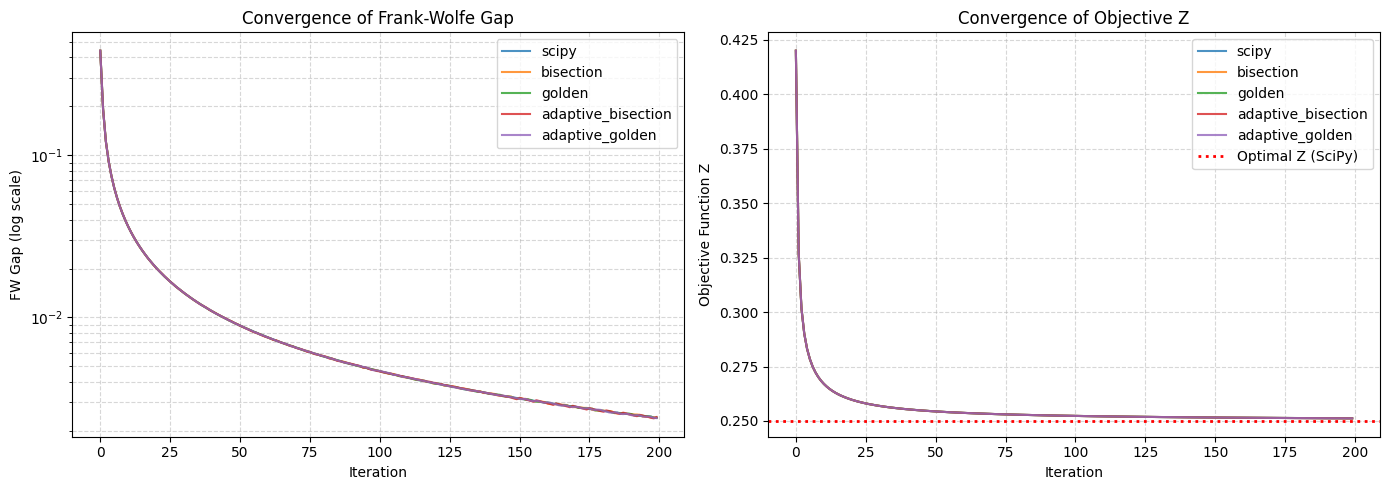

In [200]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

# 左图：FW Gap的收敛曲线 (使用对数坐标系)
plt.subplot(1, 2, 1)
for method, df_res in results.items():
    plt.plot(df_res['iter'], df_res['gap'], label=method, alpha=0.8)

plt.yscale('log')
plt.xlabel('Iteration')
plt.ylabel('FW Gap (log scale)')
plt.title('Convergence of Frank-Wolfe Gap')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()

# 右图：目标函数 Z 的收敛曲线
plt.subplot(1, 2, 2)
for method, df_res in results.items():
    plt.plot(df_res['iter'], df_res['Z'], label=method, alpha=0.8)

# 画出 SciPy 直接求解的真实最优 Z 值作为基准线
plt.axhline(y=result.fun, color='red', linestyle=':', linewidth=2, label='Optimal Z (SciPy)')

plt.xlabel('Iteration')
plt.ylabel('Objective Function Z')
plt.title('Convergence of Objective Z')
plt.grid(True, ls="--", alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

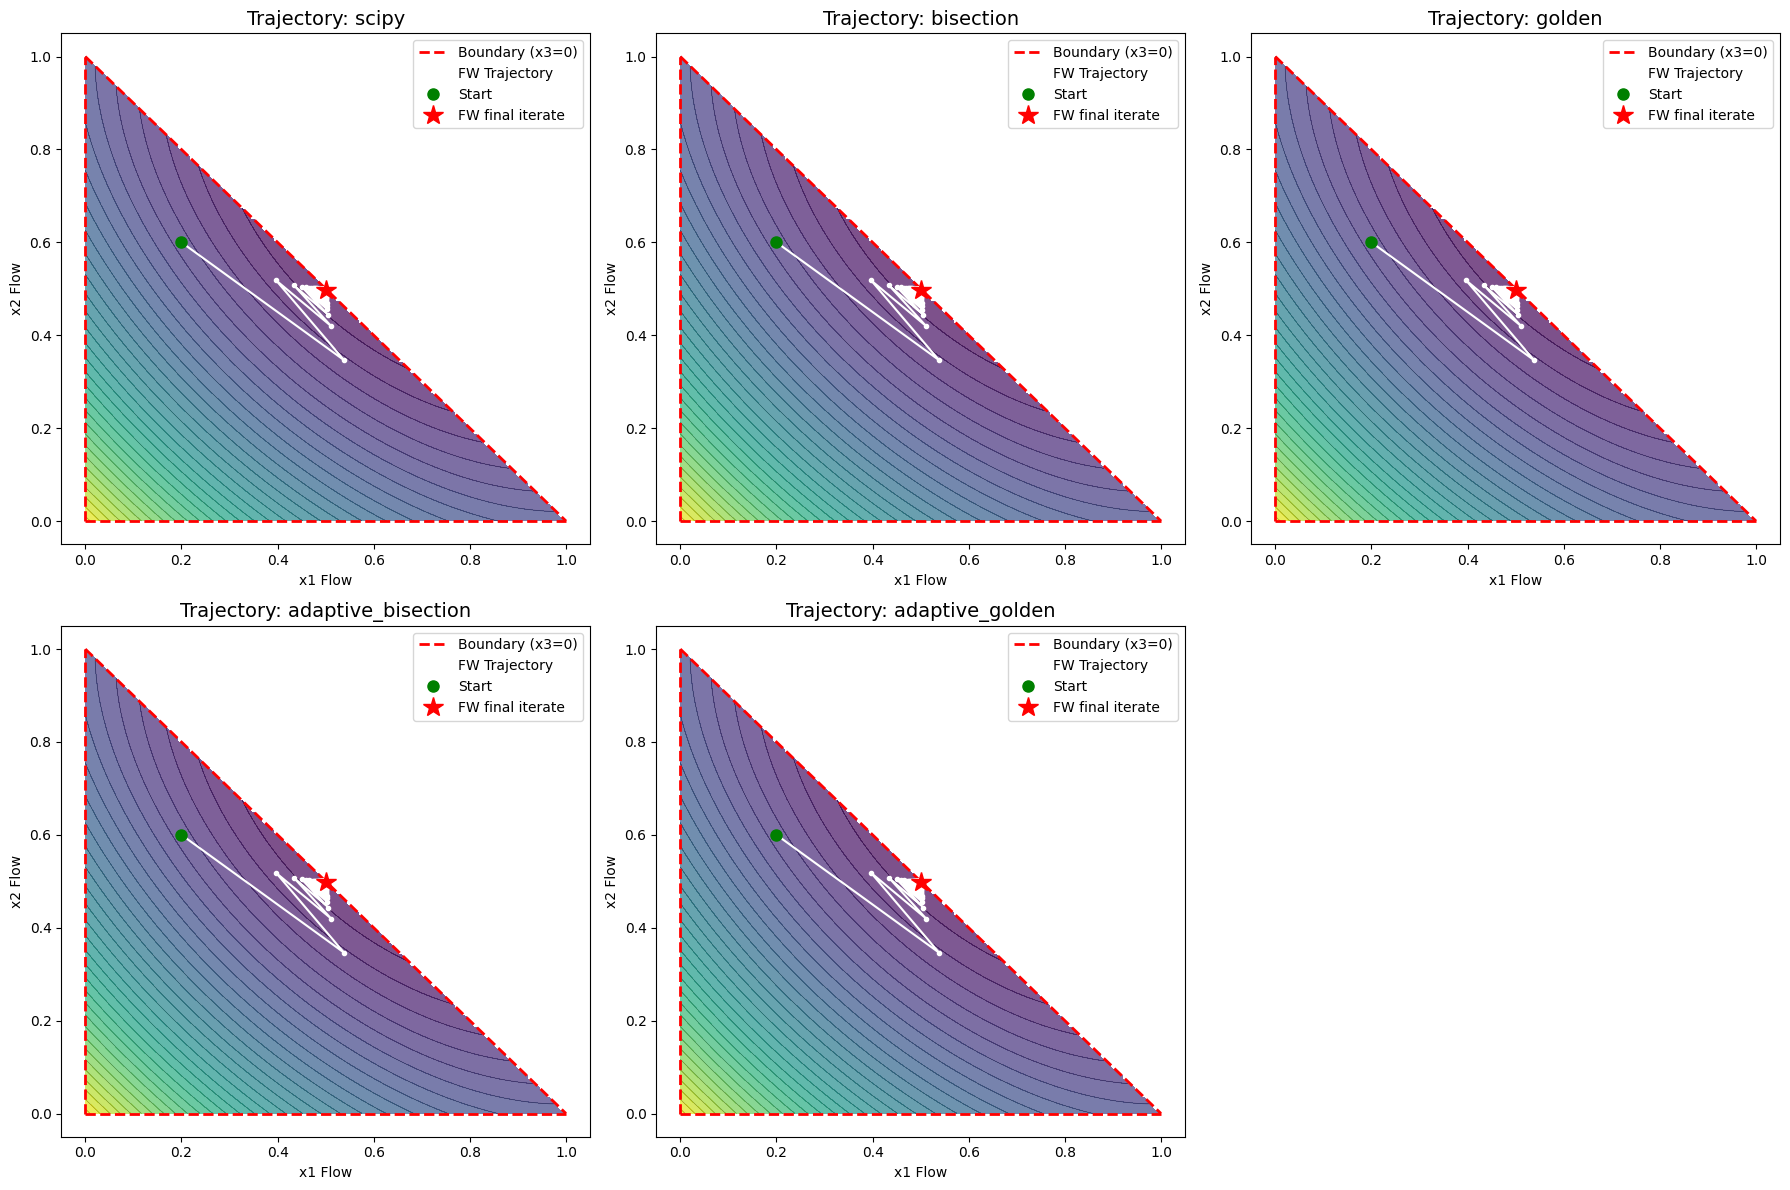

In [201]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 构造可行域的二维网格 (x1, x2)
x1_vals = np.linspace(0, 1.0, 200)
x2_vals = np.linspace(0, 1.0, 200)
X1, X2 = np.meshgrid(x1_vals, x2_vals)
X3 = 1.0 - X1 - X2  # 利用守恒约束计算 x3

# 2. 解析计算网格上每个点的目标函数 Z 值
# Z(x) = integral(t1) + integral(t2) + integral(t3)
#      = 0.5*x1^2 + 0.5*x2^2 + (0.5*x3^2 + x3)
Z_grid = 0.5 * X1**2 + 0.5 * X2**2 + 0.5 * X3**2 + X3

# 将不在可行域内的点（即 x3 < 0）设为 NaN，使其在图上不可见
Z_grid[X3 < 0] = np.nan

# 3. 开始绘图：为每个方法创建一个子图
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, (method, df_res) in enumerate(results.items()):
    ax = axes[idx]

    # 绘制目标函数的等高线
    contour = ax.contourf(X1, X2, Z_grid, levels=40, cmap='viridis', alpha=0.7)
    ax.contour(X1, X2, Z_grid, levels=40, colors='black', linewidths=0.5, alpha=0.3)

    # 绘制可行域边界 (直角三角形)
    ax.plot([0, 1], [1, 0], 'r--', lw=2, label='Boundary (x3=0)')
    ax.plot([0, 1], [0, 0], 'r--', lw=2)
    ax.plot([0, 0], [0, 1], 'r--', lw=2)

    # 提取当前方法的迭代轨迹并绘制连线
    ax.plot(df_res['x1'], df_res['x2'], 'w.-', markersize=6, linewidth=1.5, label='FW Trajectory')

    # 标记起点和终点
    ax.plot(df_res['x1'].iloc[0], df_res['x2'].iloc[0], 'go', markersize=8, label='Start')
    ax.plot(df_res['x1'].iloc[-1], df_res['x2'].iloc[-1], 'r*', markersize=15, label='FW final iterate')

    ax.set_title(f"Trajectory: {method}", fontsize=14)
    ax.set_xlabel("x1 Flow")
    ax.set_ylabel("x2 Flow")
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.legend(loc='upper right')

fig.delaxes(axes[5])

plt.tight_layout()
plt.show()